## FIShBOT sensitivity tests
When the interpolation was initiated, FIShBOT creates aggregated bottom products using a depth bin of 20 m. Here, we chose to use a 10 m depth bin to define "bottom". This creates a mismatch in the definitions of the bottom depth bin for the data used to create the bottom climatologies. Linus Stoltz (CFRF), the data manager for FIShBOT created a 10 m filter for using FIShBOT data. Here, we will conduct a sensitivity test to see the differences between the 20 m (native) FIShBOT depth bin and the special 10 m depth bin. It is preferable to use the original product if possible as it is citable and used in the scientific community. 

In [4]:
import pandas as pd
import numpy as np
import xarray as xr
import cartopy
import matplotlib.pyplot as plt
import calendar

In [5]:
#df is OG fishbot from ERDDAP
df = pd.read_csv('https://erddap.ondeckdata.com/erddap/tabledap/fishbot_realtime.csv?time%2Ctemperature%2Ctemperature_min%2Ctemperature_max%2Ctemperature_std%2Ctemperature_count%2Cdissolved_oxygen%2Cdissolved_oxygen_min%2Cdissolved_oxygen_max%2Cdissolved_oxygen_std%2Cdissolved_oxygen_count%2Csalinity%2Csalinity_min%2Csalinity_max%2Csalinity_std%2Csalinity_count%2Cdata_provider%2Cgrid_id%2Cstat_area%2Cfishery_dependent%2Cdepth%2Clatitude%2Clongitude&time%3E=2000-01-01T00%3A00%3A00Z&time%3C=2024-12-31T00%3A00%3A00Z')
df=df[1:]

#df10 is special 10 m filter fishbot
df10 = xr.open_dataset(r"C:\Users\haley.synan\Documents\DATA\fishbot_2026-08-24_10m_inclusive_depth_filter.nc")
df10 = df10.to_dataframe().reset_index()
df['time'] = pd.to_datetime(df.time)
df10['time'] = pd.to_datetime(df10.time)
df['time'] = df['time'].dt.tz_localize(None) #different tz handlings
matched_df = pd.merge(df.reset_index(), df10, on=['time', 'grid_id', 'stat_area'], how='inner') # inner merge to find equivalent observations
#note on the merge: not merging on lat/lon in case that changed with the different data from changing the depth bins

C:\Users\haley.synan\AppData\Local\Temp\ipykernel_25540\4169967605.py:2: DtypeWarning: Columns (1,2,3,4,6,7,8,9,11,12,13,14,20,21,22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('https://erddap.ondeckdata.com/erddap/tabledap/fishbot_realtime.csv?time%2Ctemperature%2Ctemperature_min%2Ctemperature_max%2Ctemperature_std%2Ctemperature_count%2Cdissolved_oxygen%2Cdissolved_oxygen_min%2Cdissolved_oxygen_max%2Cdissolved_oxygen_std%2Cdissolved_oxygen_count%2Csalinity%2Csalinity_min%2Csalinity_max%2Csalinity_std%2Csalinity_count%2Cdata_provider%2Cgrid_id%2Cstat_area%2Cfishery_dependent%2Cdepth%2Clatitude%2Clongitude&time%3E=2000-01-01T00%3A00%3A00Z&time%3C=2024-12-31T00%3A00%3A00Z')


Text(0.5, 0.98, 'Temperature differences between Fishbots with 20m and 10m depth bins')

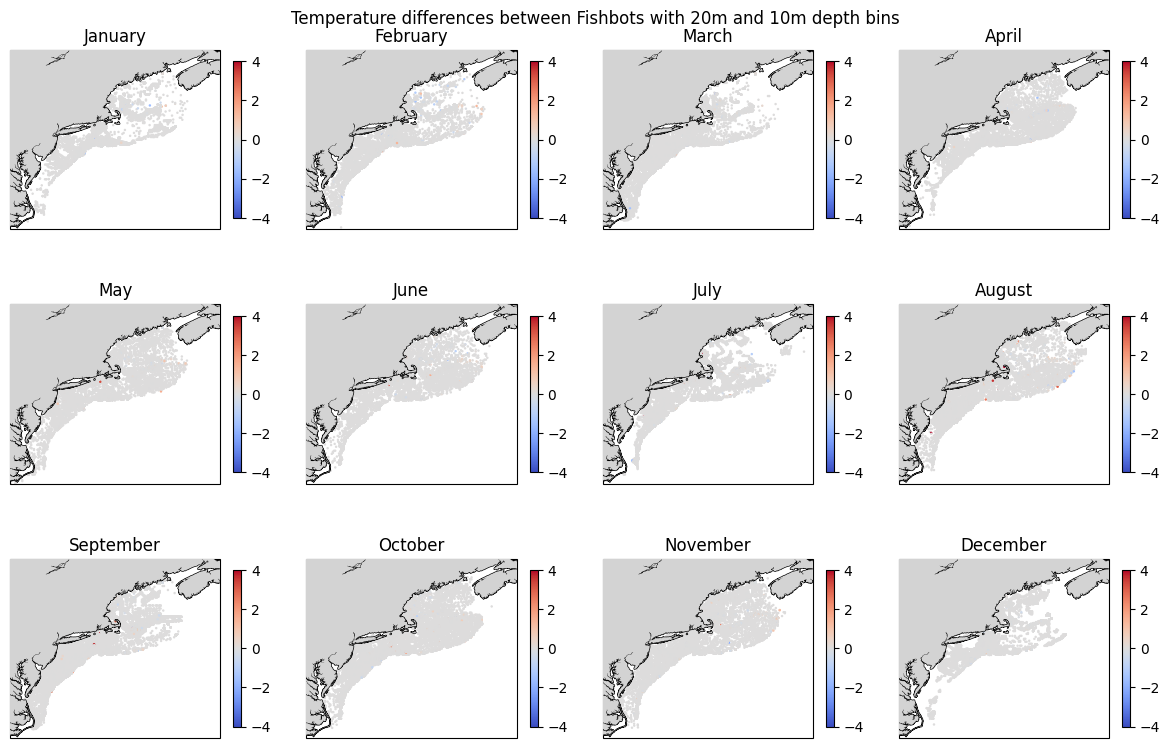

In [6]:
#plot monthly temp differences between fishbots
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(12, 8),subplot_kw={'projection': cartopy.crs.PlateCarree()})
axes_flat = axes.flatten()
for x, ax in enumerate(axes_flat):
    sub=matched_df[matched_df.time.dt.month==x+1]
    im=ax.scatter(sub.longitude_x.astype(float),sub.latitude_x.astype(float),c=sub.temperature_x.astype(float).round(3)-sub.temperature_y.astype(float).round(3),s=0.6,vmin=-4,vmax=4, cmap='coolwarm')
    ax.add_feature(cartopy.feature.COASTLINE, linewidth=1) #add coastlines
    ax.add_feature(cartopy.feature.LAND, zorder=100, facecolor='lightgrey') #add land mask 
    ax.set_extent([-77, -63.5, 34.5, 46])
    plt.colorbar(im,ax=ax,shrink=0.6)
    ax.set_title(calendar.month_name[x+1])
plt.tight_layout()
plt.suptitle('Temperature differences between Fishbots with 20m and 10m depth bins')

Text(0.5, 0.98, 'Salinity differences between Fishbots with 20m and 10m depth bins')

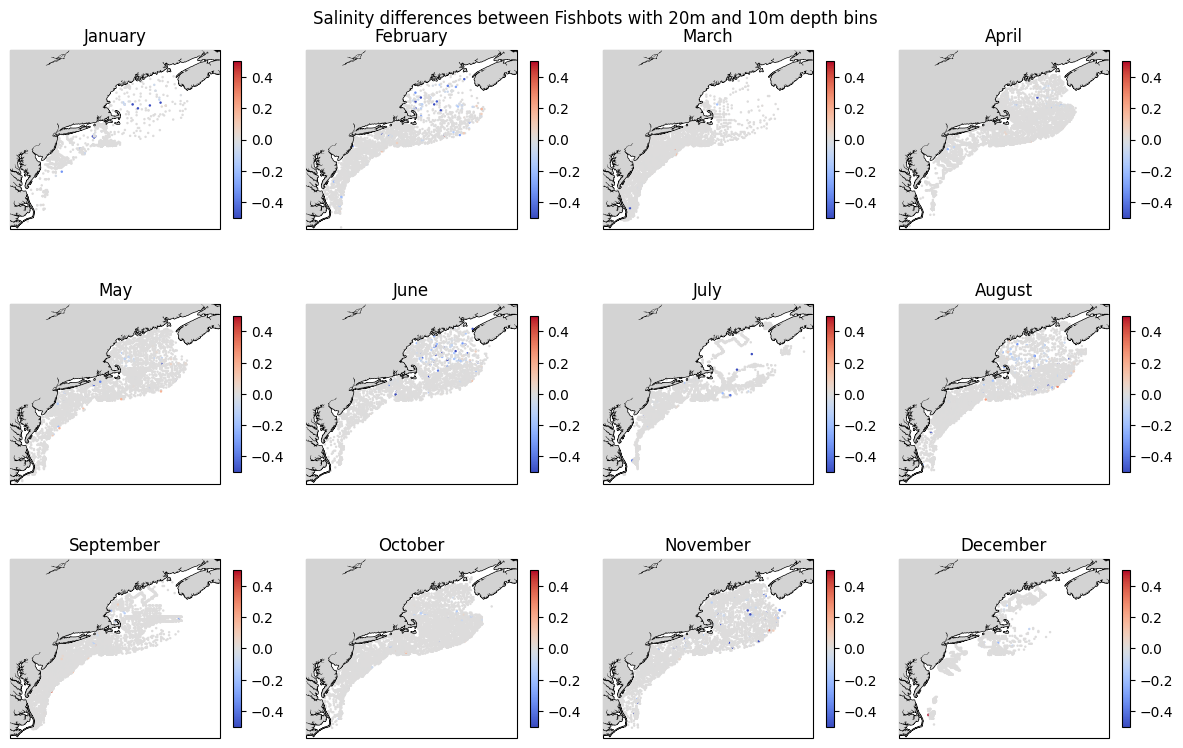

In [7]:
#plot monthly sal differences between Fishbots
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(12, 8),subplot_kw={'projection': cartopy.crs.PlateCarree()})
axes_flat = axes.flatten()
for x, ax in enumerate(axes_flat):
    sub=matched_df[matched_df.time.dt.month==x+1]
    im=ax.scatter(sub.longitude_x.astype(float),sub.latitude_x.astype(float),c=sub.salinity_x.astype(float).round(3)-sub.salinity_y.astype(float).round(3),s=0.6,vmin=-0.5,vmax=0.5, cmap='coolwarm')
    ax.add_feature(cartopy.feature.COASTLINE, linewidth=1) #add coastlines
    ax.add_feature(cartopy.feature.LAND, zorder=100, facecolor='lightgrey') #add land mask 
    ax.set_extent([-77, -63.5, 34.5, 46])
    plt.colorbar(im,ax=ax,shrink=0.6)
    ax.set_title(calendar.month_name[x+1])
plt.tight_layout()
plt.suptitle('Salinity differences between Fishbots with 20m and 10m depth bins')

There are very few differences between the Original (20m) FIShBOT and the 10m version. 

In [8]:
subs = matched_df.salinity_x.astype(float).round(3)-matched_df.salinity_y.astype(float).round(3)
subs=subs[~np.isnan(subs)]
sub=matched_df[matched_df.temperature_x.astype(float).round(3)-matched_df.temperature_y.astype(float).round(3)!=0]
print(f'{round(len(matched_df[matched_df.temperature_x.astype(float).round(3)-matched_df.temperature_y.astype(float).round(3)!=0])/len(matched_df)*100,3)}% (ie {len(sub)} observations) of the dataset has difference in temperature')
print(f'{round(len(subs[subs!=0])/len(subs)*100,3)}% (ie {len(subs[subs!=0])} observations) of the dataset has difference in salinity')
print(f'There are {len(df)} observations in the OG fishbot and {len(df10)} in the synan special fishbot') #WHY the diff???
print(f'The max temperature difference is {max(sub.temperature_x.astype(float)-sub.temperature_y.astype(float),key=abs)}')
print(f'The min temperature difference is {round(min(sub.temperature_x.astype(float)-sub.temperature_y.astype(float),key=abs),10)}')
print(f'The avg temperature difference is {abs(sub.temperature_x.astype(float)-sub.temperature_y.astype(float)).mean()}')
print(f'The max salinity difference is {np.nanmax(np.abs(sub.salinity_x.astype(float)-sub.salinity_y.astype(float)))}')
print(f'The min salinity difference is {round(np.nanmin(np.abs(sub.salinity_x.astype(float)-sub.salinity_y.astype(float))),10)}')
print(f'The avg salinity difference is {abs(sub.salinity_x.astype(float)-sub.salinity_y.astype(float)).mean()}')

3.623% (ie 6480 observations) of the dataset has difference in temperature
5.159% (ie 2915 observations) of the dataset has difference in salinity
There are 184275 observations in the OG fishbot and 228093 in the synan special fishbot
The max temperature difference is 7.445
The min temperature difference is -3.8e-09
The avg temperature difference is 0.12618247566765883
The max salinity difference is 3.2278607635498062
The min salinity difference is 0.0
The avg salinity difference is 0.07170197494726321


Text(0.5, 1.0, 'Histogram of temperature differences between\nFishbot (20m depth bin) and Fishbot (10m depth bin)')

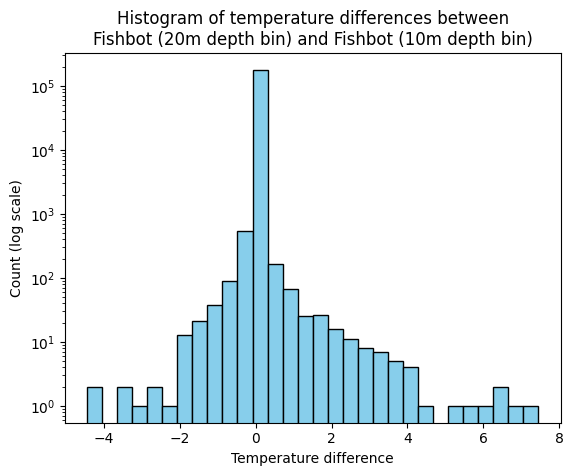

In [9]:
#plot histograms of residual distribution -- temp
#histogram
matched_df['temp_diff'] = matched_df.temperature_x.astype(float)-matched_df.temperature_y.astype(float)
matched_df['sal_diff'] = matched_df.salinity_x.astype(float)-matched_df.salinity_y.astype(float)
plt.hist(matched_df.temp_diff, bins=30,log=True, color='skyblue', edgecolor='black')
plt.xlabel('Temperature difference')
plt.ylabel('Count (log scale)')
plt.title('Histogram of temperature differences between\nFishbot (20m depth bin) and Fishbot (10m depth bin)')

Text(0.5, 1.0, 'Histogram of salinity differences between\nFishbot (20m depth bin) and Fishbot (10m depth bin)')

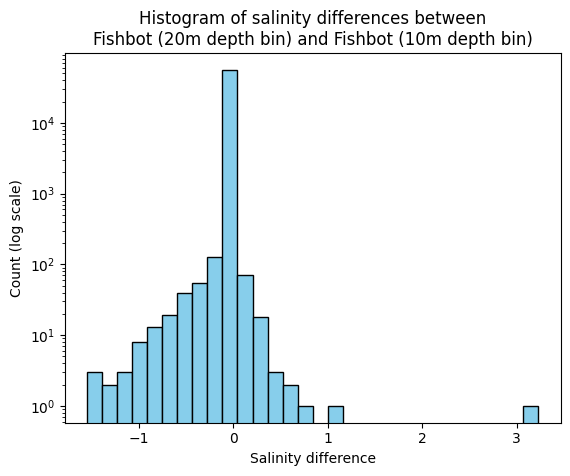

In [10]:
## Histogram of residual distribution -- sal
plt.hist(matched_df.sal_diff, bins=30,log=True, color='skyblue', edgecolor='black')
plt.xlabel('Salinity difference')
plt.ylabel('Count (log scale)')
plt.title('Histogram of salinity differences between\nFishbot (20m depth bin) and Fishbot (10m depth bin)')

In [11]:
print(f'Difference threshold of 0.5 C: results in {len(matched_df[(abs(matched_df.temp_diff)>0.5)])} data points to remove')
print(f'Difference threshold of 1 C: results in {len(matched_df[(abs(matched_df.temp_diff)>1)])} data points to remove')
print(f'Difference threshold of 2 C: results in {len(matched_df[(abs(matched_df.temp_diff)>2)])} data points to remove')
print(f'Difference threshold of 3 C: results in {len(matched_df[(abs(matched_df.temp_diff)>3)])} data points to remove')
print(f'Difference threshold of 4 C: results in {len(matched_df[(abs(matched_df.temp_diff)>4)])} data points to remove')

Difference threshold of 0.5 C: results in 407 data points to remove
Difference threshold of 1 C: results in 185 data points to remove
Difference threshold of 2 C: results in 63 data points to remove
Difference threshold of 3 C: results in 30 data points to remove
Difference threshold of 4 C: results in 13 data points to remove


In [12]:
print(f'Difference threshold of 0.1: results in {len(matched_df[(abs(matched_df.sal_diff)>0.1)])} data points to remove')
print(f'Difference threshold of 0.5: results in {len(matched_df[(abs(matched_df.sal_diff)>0.5)])} data points to remove')
print(f'Difference threshold of 0.7: results in {len(matched_df[(abs(matched_df.sal_diff)>0.7)])} data points to remove')
print(f'Difference threshold of 1: results in {len(matched_df[(abs(matched_df.sal_diff)>1)])} data points to remove')
print(f'Difference threshold of 2: results in {len(matched_df[(abs(matched_df.sal_diff)>2)])} data points to remove')

Difference threshold of 0.1: results in 346 data points to remove
Difference threshold of 0.5: results in 74 data points to remove
Difference threshold of 0.7: results in 35 data points to remove
Difference threshold of 1: results in 12 data points to remove
Difference threshold of 2: results in 1 data points to remove


We can now confidently use the true FIShBOT product, but removing some of the outliers (cells with large differences between the original 20 m FIShBOT and the 10m version). We will remove observations with more than 2 degrees C and 0.5 PSU difference. The ```df_dropped``` will be the input that will be concatenated with other sources and become the data used to create the interpolation.

In [ ]:
df_dropped = df.drop(index=list(matched_df[(abs(matched_df.temp_diff)>2) | (abs(matched_df.sal_diff)>0.5)].index)) #find rows and ditch em 
#then the idea is to use this for the interpolation.... does that make sense? 
df_dropped.to_csv(r'W:\nadata\PROJECTS\NESCAPES\SOURCE_DATA\FISHBOT\fishbot_083126_OG20m_filtered.csv')